In [1]:
import pandas, numpy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition
import scipy, scipy.signal

In [17]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/025_isafjordur/results/000_quantification/DESeq2_TPM_values.u2.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 18)


,U2-1_Sc_1h,U2-1_Sc_4h,U2-1_Sc_UT,U2-1_siMi_1h,U2-1_siMi_4h,U2-1_siMi_UT,U2-2_Sc_1h,U2-2_Sc_4h,U2-2_Sc_UT,U2-2_siMi_1h,U2-2_siMi_4h,U2-2_siMi_UT,U2-3_Sc_1h,U2-3_Sc_4h,U2-3_Sc_UT,U2-3_siMi_1h,U2-3_siMi_4h,U2-3_siMi_UT
ENSG00000000003,7.970113,3.771963,30.818057,4.253992,5.912484,6.893577,5.255392,31.151667,5.939035,39.090070,38.511241,40.127345,25.920074,26.484268,28.165731,39.713179,35.646496,36.374311
ENSG00000000005,0.000000,0.000000,0.000000,0.000000,0.008762,0.000000,0.000000,0.000000,0.000000,0.000000,0.029559,0.020145,0.000000,0.000000,0.043649,0.000000,0.075613,0.024416
ENSG00000000419,67.828012,69.938845,112.914933,63.946375,76.443936,68.466391,82.063173,120.472526,75.822065,84.174500,90.854573,87.365983,104.363435,120.767083,107.421701,91.696066,95.797235,84.883315
ENSG00000000457,5.916290,9.933899,2.598995,10.847239,6.722774,10.456216,9.018156,2.628397,10.594728,4.433342,4.370387,4.589684,2.331557,2.577461,2.507932,4.102025,4.051419,4.514144
ENSG00000000460,17.136309,21.608194,32.056208,16.203398,23.105689,16.831813,22.663994,28.521158,23.911539,10.658064,9.247266,11.772422,27.116087,29.564642,28.125365,10.855718,11.225522,11.618076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297,1.195078,0.432667,4.408266,0.363930,0.205160,0.229724,0.847572,3.629297,0.545854,2.719696,2.555119,2.258105,5.432093,4.400347,4.523390,3.705025,4.134738,4.005492
ENSG00000291298,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299,3.100814,3.087121,1.743303,2.902454,1.617588,3.476740,1.755239,1.545697,2.385269,2.558321,2.535358,2.271456,1.272163,2.022941,2.397874,1.442976,2.166450,2.192518
ENSG00000291300,0.257508,0.352276,0.455893,0.574944,0.200943,0.206109,0.297347,0.520059,0.230373,0.322094,0.616823,0.314552,0.313249,0.429957,0.362591,0.207596,0.620127,0.284173


In [6]:
for element in expression.columns:
    print(element)

U2-1_Sc_1h
U2-1_Sc_4h
U2-1_Sc_UT
U2-1_siMi_1h
U2-1_siMi_4h
U2-1_siMi_UT
U2-2_Sc_1h
U2-2_Sc_4h
U2-2_Sc_UT
U2-2_siMi_1h
U2-2_siMi_4h
U2-2_siMi_UT
U2-3_Sc_1h
U2-3_Sc_4h
U2-3_Sc_UT
U2-3_siMi_1h
U2-3_siMi_4h
U2-3_siMi_UT


# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(16564, 18)
(2721, 18)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.57942827 0.1638923 ]


U2-1_Sc_UT
U2-2_Sc_4h
U2-2_siMi_1h
U2-2_siMi_4h
U2-2_siMi_UT
U2-3_Sc_1h
U2-3_Sc_4h
U2-3_Sc_UT
U2-3_siMi_1h
U2-3_siMi_4h
U2-3_siMi_UT


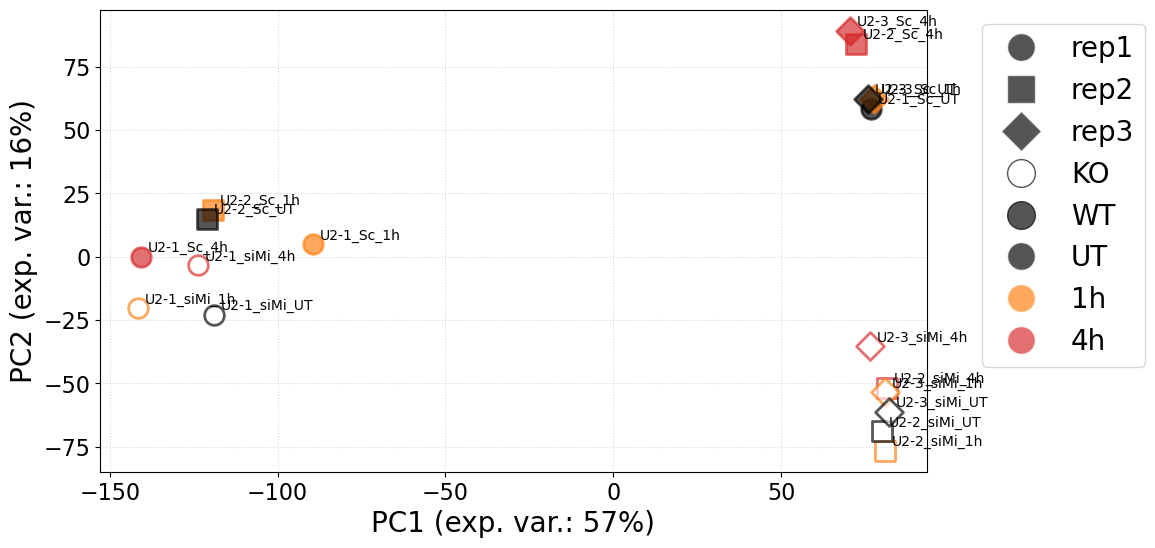

In [10]:
my_colors = ['gold']*3 + ['skyblue']*3 + ['tab:red']*3 + ['black']*3 + ['tab:green']*3
my_markers = ['o']*9 + ['s']*6

legend_elements = [
    
   matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
   matplotlib.lines.Line2D([0], [0], color='white', marker='s', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
   matplotlib.lines.Line2D([0], [0], color='white', marker='D', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
   matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='white', markeredgecolor='black', markersize=20, alpha=2/3),
   matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='black', markersize=20, alpha=2/3),
   matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
   matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:orange', markeredgecolor='white', markersize=20, alpha=2/3),
   matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3)
   
]

for i in range(len(new)):

    # treatments are colors
    if 'UT' in expression.columns[i]:
        the_ecolor = 'black'
    elif '1h' in expression.columns[i]:
        the_ecolor = 'tab:orange'
    elif '4h' in expression.columns[i]:
        the_ecolor = 'tab:red'
    else:
        the_color = 'gold'

    # genotypes are fillings
    if 'siMi' in expression.columns[i]:
        the_c = 'white'
    else:
        the_c = the_ecolor

    # replicates
    if '-1' in expression.columns[i]:
        the_marker = 'o'
    elif '-2' in expression.columns[i]:
        the_marker = 's'
    elif '-3' in expression.columns[i]:
        the_marker = 'D'

    # tagging samples:
    if new[i, 0] > 0:
        print(expression.columns[i])
    
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=200, c=the_c, marker=the_marker, alpha=2/3, edgecolors=the_ecolor, lw=2)
    epsilon = 2
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, expression.columns[i], size=10)

matplotlib.pyplot.legend(legend_elements, ['rep1', 'rep2', 'rep3', 'KO', 'WT', 'UT', '1h', '4h'], 
                         ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))

       
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')

matplotlib.pyplot.show()


# 5. visualize high expression

In [11]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.61900628 0.16793371]


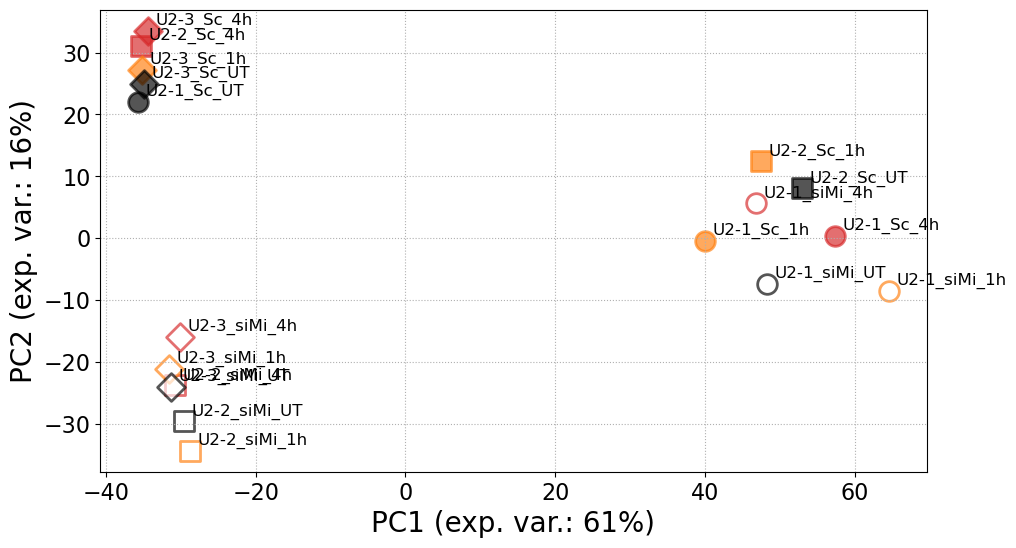

In [16]:
for i in range(len(new)):
    
    # treatments are colors
    if 'UT' in expression.columns[i]:
        the_ecolor = 'black'
    elif '1h' in expression.columns[i]:
        the_ecolor = 'tab:orange'
    elif '4h' in expression.columns[i]:
        the_ecolor = 'tab:red'
    else:
        the_color = 'gold'

    # genotypes are fillings
    if 'siMi' in expression.columns[i]:
        the_c = 'white'
    else:
        the_c = the_ecolor

    # replicates
    if '-1' in expression.columns[i]:
        the_marker = 'o'
    elif '-2' in expression.columns[i]:
        the_marker = 's'
    elif '-3' in expression.columns[i]:
        the_marker = 'D'
    
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=200, c=the_c, marker=the_marker, alpha=2/3, edgecolors=the_ecolor, lw=2)
        
    epsilon = 1
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, expression.columns[i], size=12)
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')
matplotlib.pyplot.show()

# 6. distributions

In [13]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

,U2-1_Sc_1h,U2-1_Sc_4h,U2-1_Sc_UT,U2-1_siMi_1h,U2-1_siMi_4h,U2-1_siMi_UT,U2-2_Sc_1h,U2-2_Sc_4h,U2-2_Sc_UT,U2-2_siMi_1h,U2-2_siMi_4h,U2-2_siMi_UT,U2-3_Sc_1h,U2-3_Sc_4h,U2-3_Sc_UT,U2-3_siMi_1h,U2-3_siMi_4h,U2-3_siMi_UT
ENSG00000000003,3.165126,2.254583,4.991774,2.393414,2.789204,2.980679,2.645100,5.006822,2.794735,5.325173,5.304191,5.362026,4.750610,4.780534,4.866202,5.347424,5.195603,5.223975
ENSG00000000005,0.000000,0.000000,0.000000,0.000000,0.012585,0.000000,0.000000,0.000000,0.000000,0.000000,0.042027,0.028774,0.000000,0.000000,0.061637,0.000000,0.105160,0.034802
ENSG00000000419,6.104924,6.148504,6.831813,6.021177,6.275080,6.118243,6.376137,6.924486,6.263449,6.412350,6.521280,6.465419,6.719230,6.927980,6.760510,6.534436,6.596894,6.424306
ENSG00000000457,2.789998,3.450736,1.847594,3.566479,2.949119,3.518059,3.324545,1.859332,3.535397,2.441840,2.425026,2.482767,1.736197,1.838936,1.810621,2.351070,2.336689,2.463137
ENSG00000000460,4.180809,4.498774,5.046849,4.104622,4.591302,4.156381,4.564622,4.883677,4.638742,3.543256,3.357167,3.674960,4.813324,4.933792,4.864204,3.567511,3.611824,3.657420


150
14.696425942207181


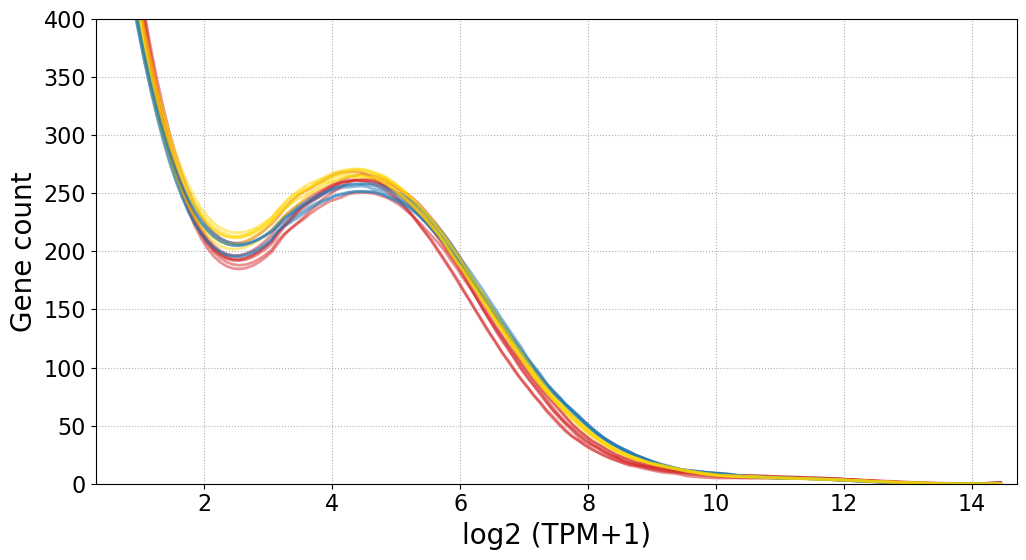

In [14]:
found_max = 15
number_of_bins = found_max*10
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    sample = working_samples[i]

    if new[i, 0] > 0: # east red
        the_color = 'tab:red'
    else:
        if new[i, 1] > 0: # north blue
            the_color = 'tab:blue'
        else:
            the_color = 'gold'
    
    
    log2TPM = log2_tpm_PO.loc[:, sample]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
   
    plotting_x = x[5:-5]
    plotting_hist = hist[5:-5]
    #print(plotting_x)
    
    #matplotlib.pyplot.plot(plotting_x, plotting_hist, '.', alpha=1/3, mec='none')
    
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)
    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=1/2, color=the_color)
    
    
    
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])
matplotlib.pyplot.ylim([0, 400])

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)